In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import factorial
from finite_diff_functions import *

# Exercise 2a
Solving the equation
$$
\begin{cases}

    \epsilon u'' + u'(u - 1) = f, & \quad 0 \le t \le 1 \\
    u(0) = \alpha, \\ u(1)= \beta
\end{cases}
$$
with DC boundary conditions
## (a)

## (b)

First we code up for a global linear BVP:

In [2]:
eps = 0.1
a = 0
b = 1
alpha = 0
beta = np.sin(1)
w0 = 0.5*(a - b + beta - alpha)
xtilde = 0.5*(a + b - alpha - beta)

# mesh
N = 4
x = np.linspace(a, b, N)
h = x[1] - x[0] # This grid is uniform

# Method of Manufactured solution (MoMS)
u_moms = lambda x: np.sin(x)
f = - (eps + 1) * np.sin(x)

stencil = np.array([-1, 0, 1])

D2 = fdcoeffV_uniform(2, x[1] - x[0], stencil) * eps
D0 = fdcoeffV_uniform(1, x[1] - x[0], stencil)
# D2 = fdcoeffV(2, x[1] - x[0], stencil) * eps
# D0 = fdcoeffV(1, x[1] - x[0], stencil)
# D2, D0
sub_diag = np.full(N-1, D2[0]) # 
d = np.full(N, D2[1])
sup_diag = np.full(N-1, D2[2])

A = np.diag(sub_diag, -1) + np.diag(d) + np.diag(sup_diag, 1) - np.eye(N)
b = np.copy(f)

# IMPOSE BC
## For RHS
b[0] = alpha
b[-1] = beta
b[1] -= A[1, 0]*alpha
b[-2] -= A[-2, -1]*beta

## System matrix
A[0,0] = 1
A[1, 0] = 0
A[0, 1] = 0

A[-1,-1] = 1
A[-2, -1] = 0
A[-1, -2] = 0

In [3]:
u_FD = np.linalg.solve(A, b)

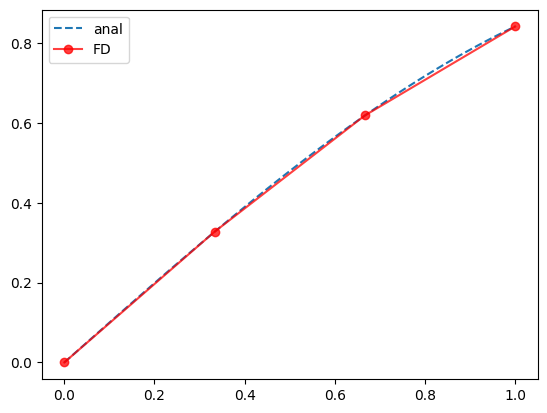

In [4]:
plt.plot(np.linspace(0,1, 100), u_moms(np.linspace(0,1,100)), '--', label = 'anal')
plt.plot(x, u_FD, 'ro-', label = 'FD', alpha = 0.75)
plt.legend()
plt.show()

G function for later

# Convergence test

In [5]:
grid_points = np.array([4, 10, 25, 50], dtype=np.int16)
h = (b - a) / (grid_points - 1)
errs = []

for N in grid_points:
    # mesh
    x = np.linspace(a, b, N)

    # Method of Manufactured solution (MoMS)
    u_moms = lambda x: np.sin(x)
    f = - (eps + 1) * np.sin(x)

    stencil = np.array([-1, 0, 1])

    D2 = fdcoeffV_uniform(2, x[1] - x[0], stencil) * eps
    D0 = fdcoeffV_uniform(1, x[1] - x[0], stencil)
    # D2 = fdcoeffV(2, x[1] - x[0], stencil) * eps
    # D0 = fdcoeffV(1, x[1] - x[0], stencil)
    # D2, D0
    sub_diag = np.full(N-1, D2[0])
    d = np.full(N, D2[1])
    sup_diag = np.full(N-1, D2[2])

    A = np.diag(sub_diag, -1) + np.diag(d) + np.diag(sup_diag, 1) - np.eye(N)

    u_FD = np.linalg.solve(A, f)

    errs.append(l2_norm(u_moms(x) - u_FD))

c:\Users\o_lor\Downloads\finite_diff_functions.py:28: RuntimeWarning: divide by zero encountered in divide
  return 1/h**k * c


ValueError: operands could not be broadcast together with shapes (4,) (3,) 

In [ ]:
plt.rc('text', usetex=True)
plt.rc('font', family='serif')


plt.loglog(h,15*h**3,"b--", label=r"$\mathcal O(h^3)$")
plt.loglog(h,errs,color="orange", label=r"$(\alpha, \beta) = (2,2)$")
plt.title("Convergence for Newtons method")
plt.grid(True, which = 'both')
plt.legend()
plt.show()

ValueError: x and y must have same first dimension, but have shapes (1,) and (0,)

Error in callback <function _draw_all_if_interactive at 0x000002AAB3B1F240> (for post_execute):


RuntimeError: Failed to process string with tex because latex could not be found

RuntimeError: Failed to process string with tex because latex could not be found

<Figure size 640x480 with 1 Axes>

### Non-linear

In [ ]:
eps = 0.1
a = 0
b = 1
alpha = -1
beta = 1.5
w0 = 0.5*(a - b + beta - alpha)
xtilde = 0.5*(a + b - alpha - beta)

# mesh
N = 4
x = np.linspace(a, b, N+1)
h = x[1] - x[0] # This grid is uniform

initial_guess = x - xtilde + w0*np.tanh(w0*(x - xtilde) / 2 * eps)


# Method of Manufactured solution (MoMS)
u_moms = lambda x: np.sin(x)
f = (np.cos(x) - eps - 1) * np.sin(x)

stencil = np.array([-1, 0, 1])

D2 = fdcoeffV_uniform(2, x[1] - x[0], stencil) * eps
D0 = fdcoeffV_uniform(1, x[1] - x[0], stencil)


sub_diag = np.full(N-1, D2[0]) # 
d = np.full(N, D2[1])
sup_diag = np.full(N-1, D2[2])

A = np.diag(sub_diag, -1) + np.diag(d) + np.diag(sup_diag, 1) - np.eye(N)
b = np.copy(f)

In [ ]:
uk = initial_guess
uk

array([-0.25703104,  0.        ,  0.25703104,  0.51406085,  0.77108819])

In [ ]:
A

array([[-2.8,  0.9,  0. ,  0. ],
       [ 0.9, -2.8,  0.9,  0. ],
       [ 0. ,  0.9, -2.8,  0.9],
       [ 0. ,  0. ,  0.9, -2.8]])

In [ ]:
def G_func(uk, A = A): # G(u) = A @ u + non_linear(u) - F
    eval_g = np.zeros_like(uk)
    dudx = (uk[2:] - uk[:-2]) / (2*h)
    eval_g[1:-1] = (A @ uk)[1:-1] - f[1:-1] + uk[1:-1] * (dudx - 1)
    eval_g[0] = uk[0] - u_moms(x[0])
    eval_g[-1] = uk[-1] - u_moms(x[-1])
    return eval_g

def Jacobian(uk, A = A, h = h):
    sub_diag = np.diag(uk[1:], -1)
    sup_diag = np.diag(uk[:-1], 1)
    main = np.eye(uk.size)
    main[1:-1, 1:-1] = np.diag(uk[2:] - uk[:-2] - 2*h)
    J = A + 1/(2*h) * (-sub_diag + main + sup_diag)
    J[0,:] = 0; J[0,0] = 1
    J[-1,:] = 0; J[-1,-1] = 1

    return J

G = G_func(uk)
J = Jacobian(uk)

uk = uk - np.linalg.solve(J,G)
uk 

array([0.        , 0.12793568, 0.39385227, 0.84147098])

In [ ]:
def G_func(u):
    n = len(u)
    G = np.zeros(n)

    for i in range(n):
        uc = u[i]
        um1 = u[i-1] if i > 0 else 0
        up1 = u[i+1] if i < n-1 else 0
        G[i] = eps/h**2*(um1-2*uc+up1)+uc*((up1-um1)/(2*h)-1)

    return G

def Jacobian(u):
    n = len(u)
    J = np.zeros((n,n))

    for i in range(n):
        uc = u[i]
        um1 = u[i-1] if i > 0 else 0
        up1 = u[i+1] if i < n-1 else 0

        for j in range(n):
            if j == i-1:
                J[i,j] = eps/h**2-uc/(2*h) 
            elif j == i +1 :
                J[i,j] = eps/h**2+uc/(2*h) 
            elif j == i:
                J[i,j] = -2*eps/h**2+(up1-um1)/(2*h) -1

    return J

In [ ]:
u_init = x

array([0.  , 0.25, 0.5 , 0.75, 1.  ])

In [ ]:
u_moms(x)

array([0.        , 0.24740396, 0.47942554, 0.68163876, 0.84147098])

In [ ]:
eps = 0.1
a = 0
b = 1

# mesh
N = 4
x = np.linspace(a, b, N+1)
h = x[1] - x[0] # This grid is uniform

u_moms = lambda x: np.sin(x)
f = (np.cos(x) - eps - 1) * np.sin(x)

u_init = x

In [ ]:
u = u_init
G = G_func(u)
J = Jacobian(u)

delta = np.linalg.solve(J,G)

u = u + delta
u

array([0.10293296, 0.73803247, 1.18975127, 1.48630176, 1.73780339])

In [ ]:
def Newton(u_init,G_func,Jacobian):
    

In [30]:
def G_func(u):
    n = len(u)
    G = np.zeros(n)

    for i in range(n):
        uc = u[i]
        um1 = u[i-1] if i > 0 else alpha
        up1 = u[i+1] if i < n-1 else beta
        G[i] = eps/h**2*(um1-2*uc+up1)+uc*((up1-um1)/(2*h)-1)-f[i]

    return G

def Jacobian(u):
    n = len(u)
    J = np.zeros((n,n))

    for i in range(n):
        uc = u[i]
        um1 = u[i-1] if i > 0 else alpha
        up1 = u[i+1] if i < n-1 else beta

        for j in range(n):
            if j == i-1:
                J[i,j] = eps/h**2-uc/(2*h) 
            elif j == i +1 :
                J[i,j] = eps/h**2+uc/(2*h) 
            elif j == i:
                J[i,j] = -2*eps/h**2+(up1-um1)/(2*h) -1

    return J

# MoMS

In [31]:
eps = 0.1
a = 0
b = 1
alpha = 0
beta = np.sin(1)


hs = []
errs = []


# mesh
N = 100

for i in range(3,10):
    h = 1/2**i
    N = int(1/h)
    x = np.linspace(a, b, N+1)
    f = -eps*np.sin(x[1:-1])+np.sin(x[1:-1])*(np.cos(x[1:-1])-1)
    u = u_moms(x[1:-1])+np.random.normal(scale=0.3,size=len(x[1:-1])) # u_init

    # Newton 
    max_iter = 100
    for k in range(max_iter):
        G = G_func(u)
        J = Jacobian(u)

        delta = np.linalg.solve(J, -G)
        u += delta

        if np.linalg.norm(delta) < 1e-12:
            break

    u_full =  np.zeros(N+1)
    u_full[0] = 0
    u_full[-1] = u_moms(1)
    u_full[1:-1] = u
    hs.append(h)
    errs.append(np.sqrt(h)*np.linalg.norm(u_full-u_moms(x),2))



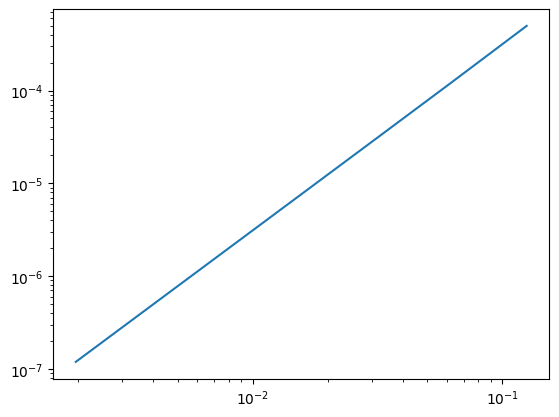

In [32]:
plt.loglog(hs,errs)

In [33]:
np.polyfit(np.log(hs[3:]),np.log(errs[3:]),1)

array([ 2.00016221, -3.46776165])

# True Problem

In [41]:
eps = 0.1
a = 0
b = 1
alpha = -1
beta = 1.5

w0 = 0.5*(a - b + beta - alpha)
xtilde = 0.5*(a + b - alpha - beta)

hs = []
errs = []

prev_u = None
prev_x = None


# mesh
N = 100

for i in range(3,10):
    h = 1/2**i
    N = int(1/h)
    x = np.linspace(a, b, N+1)
    f = np.zeros(len(x[1:-1]))
    u = initial_guess = x[1:-1] - xtilde + w0*np.tanh(w0*(x[1:-1] - xtilde) / (2 * eps)) # u_init

    # Newton 
    max_iter = 100
    for k in range(max_iter):
        G = G_func(u)
        J = Jacobian(u)

        delta = np.linalg.solve(J, -G)
        u += delta

        if np.linalg.norm(delta) < 1e-12:
            break

    u_full =  np.zeros(N+1)
    u_full[0] = alpha
    u_full[-1] = beta
    u_full[1:-1] = u

    if prev_u is not None:
        err = np.max(np.abs(u_full[::2] - prev_u))
        errs.append(err)
        hs.append(prev_h)
    
    prev_u = u_full
    prev_x = x
    prev_h = h



array([2.00119925, 1.21782622])

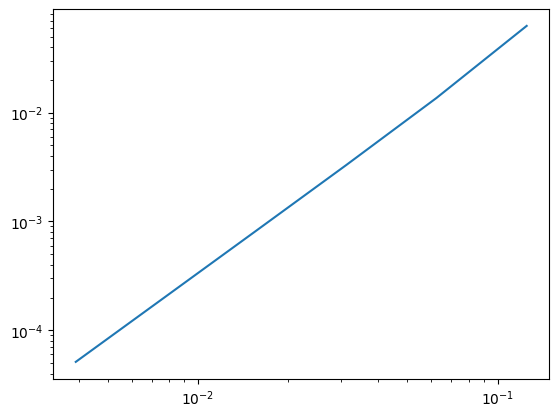

In [42]:
plt.loglog(hs,errs)
np.polyfit(np.log(hs[3:]),np.log(errs[3:]),1)